# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Veduisback/flyrank-ml-internship-starter/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [2]:
# W07 setup: recreate the validated W05/W06 modeling population

import duckdb
import pandas as pd
import numpy as np

from google.colab import userdata

HF_TOKEN = userdata.get("HF_TOKEN")
print("HF token loaded:", HF_TOKEN is not None)

con = duckdb.connect()

con.execute("INSTALL httpfs")
con.execute("LOAD httpfs")

con.execute("INSTALL azure")
con.execute("LOAD azure")

con.execute(f"""
    CREATE OR REPLACE SECRET hf_secret (
        TYPE HUGGINGFACE,
        TOKEN '{HF_TOKEN}'
    )
""")

DECISION_DATE = "2026-02-28"

FEB_PATH = (
    "hf://datasets/FlyRank/internship-warehouse/"
    "fact_content_daily_performance/month=2026-02/*.parquet"
)

MARCH_PATH = (
    "hf://datasets/FlyRank/internship-warehouse/"
    "fact_content_daily_performance/month=2026-03/*.parquet"
)

DIM_CONTENT_PATH = (
    "hf://datasets/FlyRank/internship-warehouse/"
    "dim_content.parquet"
)

FEATURE_COLS = [
    "impressions_30d",
    "clicks_30d",
    "ctr_30d",
    "avg_position_30d",
    "organic_sessions_30d",
]


# ------------------------------------------------------------
# February decision-time features
# ------------------------------------------------------------

feature_sql = f"""
WITH daily AS (
    SELECT
        client_hash_id,
        content_hash_id,
        gsc_impressions,
        gsc_clicks,
        gsc_avg_position,
        sessions_organic
    FROM read_parquet('{FEB_PATH}')
    WHERE gsc_data_available IS TRUE
),

performance AS (
    SELECT
        client_hash_id,
        content_hash_id,
        SUM(gsc_impressions) AS impressions_30d,
        SUM(gsc_clicks) AS clicks_30d,

        CASE
            WHEN SUM(gsc_impressions) > 0
            THEN SUM(gsc_clicks) * 1.0 / SUM(gsc_impressions)
            ELSE NULL
        END AS ctr_30d,

        AVG(gsc_avg_position) AS avg_position_30d,
        SUM(sessions_organic) AS organic_sessions_30d

    FROM daily

    GROUP BY
        client_hash_id,
        content_hash_id
)

SELECT *
FROM performance
"""

features_df = con.execute(feature_sql).df()


# ------------------------------------------------------------
# March outcome proxy
# ------------------------------------------------------------

outcome_sql = f"""
SELECT
    client_hash_id,
    content_hash_id,

    CASE
        WHEN SUM(COALESCE(gsc_impressions, 0)) > 0
        THEN 1
        ELSE 0
    END AS march_had_impressions

FROM read_parquet('{MARCH_PATH}')

GROUP BY
    client_hash_id,
    content_hash_id
"""

outcome_df = con.execute(outcome_sql).df()


# ------------------------------------------------------------
# Exact W04-eligible population
# ------------------------------------------------------------

eligibility_sql = f"""
SELECT
    client_hash_id,
    content_hash_id,
    content_updated_date,
    COALESCE(search_volume, 0) AS search_volume

FROM read_parquet('{DIM_CONTENT_PATH}')

WHERE content_updated_date IS NOT NULL
  AND content_updated_date <= DATE '{DECISION_DATE}'
"""

eligibility_df = con.execute(eligibility_sql).df()


# ------------------------------------------------------------
# Build the exact W05/W06 modeling frame
# ------------------------------------------------------------

model_df = (
    features_df
    .merge(
        outcome_df,
        on=["client_hash_id", "content_hash_id"],
        how="left"
    )
    .merge(
        eligibility_df,
        on=["client_hash_id", "content_hash_id"],
        how="inner"
    )
)

model_df["march_had_impressions"] = (
    model_df["march_had_impressions"]
    .fillna(0)
    .astype(int)
)

model_df = model_df.dropna(
    subset=FEATURE_COLS + ["march_had_impressions"]
).copy()


print("W07 modeling frame shape:", model_df.shape)
print("Unique clients:", model_df["client_hash_id"].nunique())

print("\nTarget distribution:")
display(
    model_df["march_had_impressions"]
    .value_counts()
    .sort_index()
    .rename_axis("march_had_impressions")
    .reset_index(name="n")
)

HF token loaded: True


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

W07 modeling frame shape: (16309, 10)
Unique clients: 17

Target distribution:


,march_had_impressions,n
0,0,1870
1,1,14439


## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

Why it matters: A model score is not the final product. The output must become a clear, human-reviewed content action playbook with known limits — and this playbook becomes the recommendations section of your deployed research paper, so building it well now saves you the whole week after.

Your job: Create a notebook that turns your validated output into a content action playbook. Include ranked actions with reason codes, archetype→action mapping, the decay/refresh insight, intended use, limits, human-review rules, cost/value thinking, and light monitoring/retrain triggers. State clearly what should NOT be automated. Have the notebook export the ranked queue (and any figures you want to reuse) to work/outputs/ — those exact files are what your paper will build on next week.

Deliverable: your repo URL — with work/notebooks/w07_action_playbook.ipynb executed and committed (exports live in work/outputs/).

What done looks like: explains intended use, ranked actions, reason codes, human review, monitoring/retrain triggers, cost/value, and no-go cases; exports the queue for the paper; keeps the plan practical and non-production.

Where this lives: in your repo, under work/notebooks/ — commit it there, then submit on this card. Done.

Your skeleton is ready: open work/notebooks/w07_action_playbook.ipynb — the sections are pre-made; fill them in order: 1) Ranked actions + reason codes → 2) Intended use and limits → 3) Human review + the no-go list → 4) Monitoring / retrain triggers → 5) Exports for the paper → 6) Self-check.

Working with an AI assistant? Tell it to read skills/README.md in your repo, then load writing-honest-claims + flyrank/flyrank-data for this task.

About the exports: the queue CSV in work/outputs/ stays out of git by design (the CI leak-guard blocks data files; your notebook regenerates it). Commit the figures you’ll reuse to work/figures/, and keep your metrics JSONs committed — they’re the receipts your paper’s numbers trace back to.

In [3]:
# Section 1: Build the ranked content action queue

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. Train the validated model on the full W05 modeling frame
# ------------------------------------------------------------

final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

final_model.fit(
    model_df[FEATURE_COLS],
    model_df["march_had_impressions"]
)

model_df["model_score"] = final_model.predict_proba(
    model_df[FEATURE_COLS]
)[:, 1]


# ------------------------------------------------------------
# 2. Recreate the W04 baseline score
# ------------------------------------------------------------

model_df["days_since_update"] = (
    pd.Timestamp(DECISION_DATE)
    - pd.to_datetime(model_df["content_updated_date"])
).dt.days

model_df["baseline_score"] = (
    model_df["days_since_update"].clip(lower=0)
    * np.log1p(model_df["search_volume"].fillna(0))
)


# ------------------------------------------------------------
# 3. Define practical review signals
# ------------------------------------------------------------

model_df["is_stale"] = (
    model_df["days_since_update"] >= 180
)

model_df["has_search_demand"] = (
    model_df["search_volume"].fillna(0) > 0
)

model_df["high_model_signal"] = (
    model_df["model_score"] >= 0.75
)


# ------------------------------------------------------------
# 4. Assign reason codes
# ------------------------------------------------------------

model_df["reason_code"] = np.select(
    [
        model_df["high_model_signal"] & model_df["is_stale"],
        model_df["high_model_signal"],
        model_df["is_stale"] & model_df["has_search_demand"],
    ],
    [
        "HIGH_SIGNAL_STALE",
        "HIGH_MODEL_SIGNAL",
        "STALE_DEMAND",
    ],
    default="MONITOR"
)


# ------------------------------------------------------------
# 5. Map reason codes to human-review actions
# ------------------------------------------------------------

action_map = {
    "HIGH_SIGNAL_STALE": "REFRESH_REVIEW",
    "HIGH_MODEL_SIGNAL": "PROTECT_REVIEW",
    "STALE_DEMAND": "REFRESH_REVIEW",
    "MONITOR": "MONITOR",
}

model_df["action"] = model_df["reason_code"].map(action_map)


# ------------------------------------------------------------
# 6. Rank the queue
# ------------------------------------------------------------

action_queue = (
    model_df[
        [
            "client_hash_id",
            "content_hash_id",
            "content_updated_date",
            "days_since_update",
            "search_volume",
            "baseline_score",
            "model_score",
            "reason_code",
            "action",
        ]
    ]
    .sort_values(
        [
            "model_score",
            "baseline_score",
            "client_hash_id",
            "content_hash_id",
        ],
        ascending=[False, False, True, True]
    )
    .reset_index(drop=True)
)

action_queue.insert(
    0,
    "rank",
    np.arange(1, len(action_queue) + 1)
)


# ------------------------------------------------------------
# 7. Basic audit
# ------------------------------------------------------------

print("Ranked action queue")
print("=" * 70)

print("Rows:", len(action_queue))
print("Unique clients:", action_queue["client_hash_id"].nunique())
print("Missing model scores:", action_queue["model_score"].isna().sum())
print("Missing reason codes:", action_queue["reason_code"].isna().sum())
print("Missing actions:", action_queue["action"].isna().sum())

print("\nReason-code distribution:")
display(
    action_queue["reason_code"]
    .value_counts()
    .rename_axis("reason_code")
    .reset_index(name="n")
)

print("\nTop 20 ranked actions:")
display(action_queue.head(20))

Ranked action queue
Rows: 16309
Unique clients: 17
Missing model scores: 0
Missing reason codes: 0
Missing actions: 0

Reason-code distribution:


,reason_code,n
0,HIGH_MODEL_SIGNAL,12787
1,MONITOR,3469
2,HIGH_SIGNAL_STALE,53



Top 20 ranked actions:


,rank,client_hash_id,content_hash_id,content_updated_date,days_since_update,search_volume,baseline_score,model_score,reason_code,action
0,1,client_3197e6291363b4db,content_76388640718bd4b9,2026-02-25,3,1000,20.726264,1.0,HIGH_MODEL_SIGNAL,PROTECT_REVIEW
1,2,client_3197e6291363b4db,content_c128c2be614b343e,2026-02-25,3,880,20.343173,1.0,HIGH_MODEL_SIGNAL,PROTECT_REVIEW
2,3,client_3197e6291363b4db,content_daac9ae9039aedaf,2026-02-25,3,720,19.741917,1.0,HIGH_MODEL_SIGNAL,PROTECT_REVIEW
3,4,client_3197e6291363b4db,content_f146d3ce3ad5cea2,2026-02-25,3,590,19.145448,1.0,HIGH_MODEL_SIGNAL,PROTECT_REVIEW
4,5,client_3197e6291363b4db,content_b1c7f8629cc61d93,2026-02-25,3,480,18.527602,1.0,HIGH_MODEL_SIGNAL,PROTECT_REVIEW
5,6,client_3197e6291363b4db,content_22588e765b93dfac,2026-02-25,3,390,17.906123,1.0,HIGH_MODEL_SIGNAL,PROTECT_REVIEW
6,7,client_3197e6291363b4db,content_33c141e04352003a,2026-02-25,3,390,17.906123,1.0,HIGH_MODEL_SIGNAL,PROTECT_REVIEW
7,8,client_3197e6291363b4db,content_b4a9bc689d742e15,2026-02-25,3,390,17.906123,1.0,HIGH_MODEL_SIGNAL,PROTECT_REVIEW
8,9,client_3197e6291363b4db,content_d6a559d9a93a3eac,2026-02-25,3,390,17.906123,1.0,HIGH_MODEL_SIGNAL,PROTECT_REVIEW
9,10,client_b10cb2997d0c7c86,content_1c682f74381c8c00,2026-02-25,3,390,17.906123,1.0,HIGH_MODEL_SIGNAL,PROTECT_REVIEW


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

## 2. Intended use and limits

### Intended use

The ranked queue is intended to help editorial or SEO reviewers prioritize which content items to inspect first.

The model score is used as a **ranking signal** for human review. It is not treated as proof that a page needs a refresh, nor as a prediction of the value of making a specific content change.

The queue combines:

* the model ranking signal from decision-time performance features,
* the W04 staleness-and-demand baseline score,
* content age relative to the fixed decision date,
* search-volume context,
* and a reason code that explains why an item was surfaced.

The intended workflow is:

**rank → inspect evidence → apply human judgment → decide whether an action is appropriate → record the decision.**

### What the model output means

`model_score` represents the model's ranking signal for the historical outcome proxy `march_had_impressions`.

It should not be interpreted as:

* a guaranteed probability of future traffic,
* expected traffic growth,
* expected business value,
* evidence that refreshing the page will cause improvement,
* or a production-quality decision threshold.

The `0.75` high-signal cutoff used in this notebook is a **review-queue heuristic**, not a validated business threshold.

### Validation scope

The earlier grouped-client validation measured a ROC-AUC of approximately `0.718` and AP of approximately `0.964` on four held-out clients.

That result supports describing the model as providing a **directional ranking signal on the evaluated held-out-client population**.

It does not establish:

* production performance,
* causal impact of refreshing content,
* performance on every client,
* or the business value of actions taken from the queue.

The final queue is therefore a practical research artifact for human-reviewed prioritization rather than an automated production system.

### Decay and refresh insight

The earlier staleness analysis showed that content age can provide useful review context, but the observed relationship was not sufficient to conclude that older content should automatically be refreshed.

The staleness buckets also had uneven data coverage. In particular, the oldest `366+` bucket did not provide a reliable matched-impression comparison.

Therefore, staleness is used here as **supporting evidence**, not as an automatic refresh rule.

The playbook should be refreshed when new decision-time data and outcome labels become available, especially if the content population, client mix, or feature distributions change materially.

### Limits

This playbook has several important limits:

1. The outcome is `march_had_impressions`, an outcome proxy rather than a direct measure of successful content refresh.
2. The validation population contains a limited number of clients, including four held-out clients in the grouped evaluation.
3. The model was evaluated on historical data and has not been demonstrated in production.
4. The reason-code thresholds are heuristic design choices.
5. Model scores are not treated as calibrated probabilities.
6. A high score does not establish that a content change will improve performance.
7. Search volume and staleness provide context but do not establish causal value.
8. Changes in client mix, content mix, tracking, or data availability can reduce the usefulness of the ranking.

For these reasons, every recommended action remains subject to human review.


In [4]:
# Section 2: Summarize intended-use context and queue composition

print("W07 Action Playbook — Intended-use context")
print("=" * 70)

print(f"Decision date: {DECISION_DATE}")
print(f"Modeling population: {len(model_df):,} content items")
print(f"Unique clients: {model_df['client_hash_id'].nunique():,}")

print("\nQueue composition:")
display(
    action_queue.groupby(
        ["reason_code", "action"],
        as_index=False
    )
    .size()
    .rename(columns={"size": "n"})
    .sort_values("n", ascending=False)
)

print("\nModel-score summary:")
display(
    action_queue["model_score"]
    .describe()
    .to_frame("model_score")
)

print("\nStaleness summary:")
display(
    action_queue["days_since_update"]
    .describe()
    .to_frame("days_since_update")
)

print("\nHigh-signal items:")
print(
    f"{action_queue['high_model_signal'].sum():,}"
    if "high_model_signal" in action_queue.columns
    else "High-signal count is represented by reason codes."
)

W07 Action Playbook — Intended-use context
Decision date: 2026-02-28
Modeling population: 16,309 content items
Unique clients: 17

Queue composition:


,reason_code,action,n
0,HIGH_MODEL_SIGNAL,PROTECT_REVIEW,12787
2,MONITOR,MONITOR,3469
1,HIGH_SIGNAL_STALE,REFRESH_REVIEW,53



Model-score summary:


,model_score
count,16309.000000
mean,0.885423
std,0.113066
min,0.450349
25%,0.758666
50%,0.924781
75%,0.999655
max,1.000000



Staleness summary:


,days_since_update
count,16309.000000
mean,9.136918
std,27.227538
min,1.000000
25%,3.000000
50%,3.000000
75%,3.000000
max,272.000000



High-signal items:
High-signal count is represented by reason codes.


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

## 3. Human review rules and no-go list

The action queue is designed for **human-in-the-loop review**. A queue entry is a prioritization signal, not an instruction to modify content.

### Human review rules

Before taking any content action, the reviewer should:

1. **Inspect the actual page/content.**
   The model does not see the full editorial context needed to decide whether a change is appropriate.

2. **Verify the reason code.**
   Confirm that the supporting evidence matches the surfaced pattern, such as staleness, search demand, or model signal.

3. **Check current search intent.**
   A page may be old while still being appropriate for its intended query, or a recent page may require attention for reasons not represented by the model.

4. **Check factual and editorial freshness.**
   For refresh candidates, verify whether information, examples, links, statistics, product details, or recommendations are outdated.

5. **Check business and content constraints.**
   Reviewers should consider ownership, brand requirements, legal/compliance requirements, strategic importance, and other context unavailable to the model.

6. **Record the decision.**
   The reviewer should record whether the recommendation was accepted, rejected, deferred, or modified and, where practical, the reason.

7. **Escalate ambiguous cases.**
   Items with conflicting evidence, sensitive content, high business impact, or unclear ownership should receive additional human review rather than being automatically acted upon.

### Cost/value thinking

Review capacity is limited, so the queue should be treated as a way to allocate **review attention**, not as a mechanism for automatically maximizing business value.

A practical review-priority question is:

> Is the expected value of spending reviewer time on this item sufficient to justify the review cost and uncertainty?

Factors that can increase the value of review include:

* strong model ranking signal,
* meaningful search demand,
* substantial content age,
* clear evidence that the content may need factual or editorial review,
* and a realistic opportunity to make a useful change.

Factors that can reduce priority include:

* weak or conflicting evidence,
* very low demand,
* high uncertainty about the appropriate action,
* high review effort,
* or insufficient information to justify a change.

No monetary value is assigned by this notebook because the available evaluation data does not establish a reliable monetary relationship between a review action and business outcome.

### What should NOT be automated

The following actions should remain explicitly outside the scope of this playbook:

* automatically publishing content changes;
* automatically rewriting pages;
* automatically changing titles, headings, metadata, or keywords;
* automatically deleting or pruning content;
* automatically redirecting URLs;
* automatically changing canonical URLs;
* automatically changing internal-link structures;
* automatically declaring a page successful or unsuccessful based only on the model score;
* automatically claiming that a refresh caused traffic improvement;
* automatically applying the queue to clients without human review;
* automatically retraining and deploying a new model without validation.

The model can prioritize **what to inspect**. It should not independently decide **what content change to make** or deploy that change.


In [5]:
# Section 3: Human-review policy and no-go automation checks

NO_GO_ACTIONS = [
    "AUTO_PUBLISH",
    "AUTO_REWRITE",
    "AUTO_DELETE",
    "AUTO_PRUNE",
    "AUTO_REDIRECT",
    "AUTO_METADATA_CHANGE",
    "AUTO_CANONICAL_CHANGE",
    "AUTO_INTERNAL_LINK_CHANGE",
    "AUTO_DEPLOY",
]

REVIEW_ACTIONS = {
    "REFRESH_REVIEW": "Human review required before any refresh decision",
    "PROTECT_REVIEW": "Human review required before changing existing content",
    "MONITOR": "Monitor; no immediate content change recommended",
}

print("Human-review policy")
print("=" * 70)

for action, rule in REVIEW_ACTIONS.items():
    print(f"{action:18s} -> {rule}")

print("\nExplicit no-go automation actions:")
for action in NO_GO_ACTIONS:
    print(f"  - {action}")

print("\nQueue actions requiring human review:")
print(
    action_queue["action"]
    .value_counts()
    .rename_axis("action")
    .reset_index(name="n")
)

Human-review policy
REFRESH_REVIEW     -> Human review required before any refresh decision
PROTECT_REVIEW     -> Human review required before changing existing content
MONITOR            -> Monitor; no immediate content change recommended

Explicit no-go automation actions:
  - AUTO_PUBLISH
  - AUTO_REWRITE
  - AUTO_DELETE
  - AUTO_PRUNE
  - AUTO_REDIRECT
  - AUTO_METADATA_CHANGE
  - AUTO_CANONICAL_CHANGE
  - AUTO_INTERNAL_LINK_CHANGE
  - AUTO_DEPLOY

Queue actions requiring human review:
           action      n
0  PROTECT_REVIEW  12787
1         MONITOR   3469
2  REFRESH_REVIEW     53


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

## 4. Monitoring and retrain triggers

The playbook is a research-stage decision-support artifact. Monitoring should focus on whether the ranking signal remains useful and whether the data or operating environment has changed.

### Routine monitoring

A recurring review should track:

* distribution of `model_score`;
* share of items in each reason code;
* share of items in each suggested action;
* client coverage and client mix;
* missing or invalid feature values;
* feature distributions compared with the validation population;
* volume of items entering the queue;
* reviewer acceptance, rejection, deferral, and modification rates;
* downstream outcome metrics when new labeled data becomes available.

The monitoring process should distinguish **model behavior** from **business outcomes**. A change in the number of high-score items does not by itself demonstrate a change in content quality or business value.

### Suggested monitoring cadence

For a practical research workflow:

* **Per run:** validate schema, missingness, row counts, score availability, and reason-code coverage.
* **Weekly or per review cycle:** inspect queue composition, reviewer decisions, and unusual client or content concentration.
* **Monthly or when sufficient new labels are available:** re-evaluate ranking performance using a time-appropriate validation set.

These are operating recommendations rather than validated production requirements.

### Monitoring triggers

Investigate the playbook when any of the following occurs:

1. A large unexpected change occurs in the model-score distribution.
2. One reason code becomes unusually dominant or disappears.
3. Client coverage changes materially.
4. Required features become missing, malformed, or unavailable.
5. Feature distributions move substantially away from the validation population.
6. Reviewer decisions consistently disagree with the suggested action.
7. New outcome labels show materially weaker ranking performance than the previous evaluation.
8. The content population or data-generation process changes.

### Retraining triggers

Retraining should be considered when:

* new labeled outcome data represents a materially different time period;
* new clients or content types are introduced;
* feature definitions or source systems change;
* monitored feature distributions show sustained drift;
* ranking performance degrades on an appropriate time-based or grouped validation set;
* reviewer feedback reveals systematic failure patterns;
* or the business question represented by the target changes.

Retraining should **not** be triggered solely because a reviewer disagrees with an individual recommendation.

### Validation requirement before reuse

A retrained model should not automatically replace the current model.

Before reuse, the new model should be evaluated using an appropriate holdout design, with particular attention to client or time separation where relevant. The evaluation should compare ranking metrics and practical queue behavior against the previous version.

The new model should only become the basis for a future action queue after the validation results and limitations have been documented.

### Monitoring principle

The central monitoring question is:

> Does the model remain a useful and appropriately interpreted ranking signal for the review workflow?

This is different from asking whether the model can independently decide which content should be changed.


In [6]:
# Section 4: Monitoring snapshot
#
# This creates a lightweight baseline that future runs can compare against.

monitoring_snapshot = {
    "decision_date": DECISION_DATE,
    "rows": int(len(action_queue)),
    "unique_clients": int(action_queue["client_hash_id"].nunique()),
    "model_score_mean": float(action_queue["model_score"].mean()),
    "model_score_std": float(action_queue["model_score"].std()),
    "model_score_min": float(action_queue["model_score"].min()),
    "model_score_max": float(action_queue["model_score"].max()),
    "high_model_signal_share": float(
        (action_queue["model_score"] >= 0.75).mean()
    ),
    "reason_code_counts": (
        action_queue["reason_code"]
        .value_counts()
        .to_dict()
    ),
    "action_counts": (
        action_queue["action"]
        .value_counts()
        .to_dict()
    ),
}

print("Monitoring snapshot")
print("=" * 70)

for key, value in monitoring_snapshot.items():
    print(f"{key}: {value}")

Monitoring snapshot
decision_date: 2026-02-28
rows: 16309
unique_clients: 17
model_score_mean: 0.8854230388914344
model_score_std: 0.11306551223001773
model_score_min: 0.4503493740508083
model_score_max: 1.0
high_model_signal_share: 0.7872953583910725
reason_code_counts: {'HIGH_MODEL_SIGNAL': 12787, 'MONITOR': 3469, 'HIGH_SIGNAL_STALE': 53}
action_counts: {'PROTECT_REVIEW': 12787, 'MONITOR': 3469, 'REFRESH_REVIEW': 53}


In [7]:
# Section 4: Automated data-quality checks for each queue build

monitoring_checks = {
    "queue_not_empty": len(action_queue) > 0,
    "no_missing_model_scores": action_queue["model_score"].notna().all(),
    "no_missing_reason_codes": action_queue["reason_code"].notna().all(),
    "no_missing_actions": action_queue["action"].notna().all(),
    "valid_rank_sequence": (
        action_queue["rank"].to_numpy()
        == np.arange(1, len(action_queue) + 1)
    ).all(),
    "valid_model_score_range": (
        action_queue["model_score"].between(0, 1).all()
    ),
    "all_actions_have_review_policy": (
        action_queue["action"].isin(REVIEW_ACTIONS.keys()).all()
    ),
}

print("Monitoring checks")
print("=" * 70)

for check, passed in monitoring_checks.items():
    print(f"{'PASS' if passed else 'FAIL'}  {check}")

assert all(monitoring_checks.values()), "Monitoring check failed."

print("\nAll monitoring checks passed.")

Monitoring checks
PASS  queue_not_empty
PASS  no_missing_model_scores
PASS  no_missing_reason_codes
PASS  no_missing_actions
PASS  valid_rank_sequence
PASS  valid_model_score_range
PASS  all_actions_have_review_policy

All monitoring checks passed.


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

## 5. Exports for the paper

The notebook exports the ranked queue and supporting evidence so that the deployed research paper can reference the same artifacts generated by this analysis.

The queue CSV is regenerated by the notebook and intentionally remains outside version control because it contains row-level data.

The metrics JSON and figures are compact research receipts that document the queue composition and can be committed for reproducibility.

### Exported artifacts

* `work/outputs/w07_ranked_action_queue.csv`

  * Full ranked review queue.
  * Regenerated from the notebook.
  * Not committed to Git.

* `work/outputs/w07_playbook_metrics.json`

  * Queue size, client coverage, score summary, reason-code counts, and action counts.
  * Committed as a reproducibility receipt.

* `work/figures/w07_reason_code_distribution.png`

  * Distribution of queue reason codes.

* `work/figures/w07_model_score_distribution.png`

  * Distribution of model ranking scores.

These files are intended to provide the factual basis for the recommendations and action-playbook discussion in the research paper.


In [8]:
# Section 5: Export queue and metrics for the research paper

from pathlib import Path
import json

OUTPUT_DIR = Path("work/outputs")
FIGURE_DIR = Path("work/figures")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# 1. Ranked queue
# ------------------------------------------------------------

QUEUE_PATH = OUTPUT_DIR / "w07_ranked_action_queue.csv"

action_queue.to_csv(
    QUEUE_PATH,
    index=False
)


# ------------------------------------------------------------
# 2. Metrics / reproducibility receipt
# ------------------------------------------------------------

metrics = {
    "artifact": "w07_action_playbook",
    "decision_date": DECISION_DATE,
    "modeling_population_rows": int(len(model_df)),
    "unique_clients": int(model_df["client_hash_id"].nunique()),

    "model_score": {
        "mean": float(action_queue["model_score"].mean()),
        "std": float(action_queue["model_score"].std()),
        "min": float(action_queue["model_score"].min()),
        "max": float(action_queue["model_score"].max()),
        "high_signal_threshold": 0.75,
        "high_signal_share": float(
            (action_queue["model_score"] >= 0.75).mean()
        ),
    },

    "reason_code_counts": {
        str(k): int(v)
        for k, v in action_queue["reason_code"]
        .value_counts()
        .to_dict()
        .items()
    },

    "action_counts": {
        str(k): int(v)
        for k, v in action_queue["action"]
        .value_counts()
        .to_dict()
        .items()
    },

    "validation_reference": {
        "grouped_client_roc_auc": 0.7179,
        "grouped_client_average_precision": 0.9642,
        "held_out_clients": 4
    },

    "interpretation": (
        "The model score is used as a directional ranking signal "
        "for human review. It is not treated as a calibrated "
        "probability or an automatic content-action decision."
    )
}

METRICS_PATH = OUTPUT_DIR / "w07_playbook_metrics.json"

with open(METRICS_PATH, "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=2)


print("Exports created")
print("=" * 70)
print(f"Queue:   {QUEUE_PATH}")
print(f"Metrics: {METRICS_PATH}")

print("\nQueue rows:", len(action_queue))
print("Queue columns:", len(action_queue.columns))
print("Metrics keys:", len(metrics))

Exports created
Queue:   work/outputs/w07_ranked_action_queue.csv
Metrics: work/outputs/w07_playbook_metrics.json

Queue rows: 16309
Queue columns: 10
Metrics keys: 9


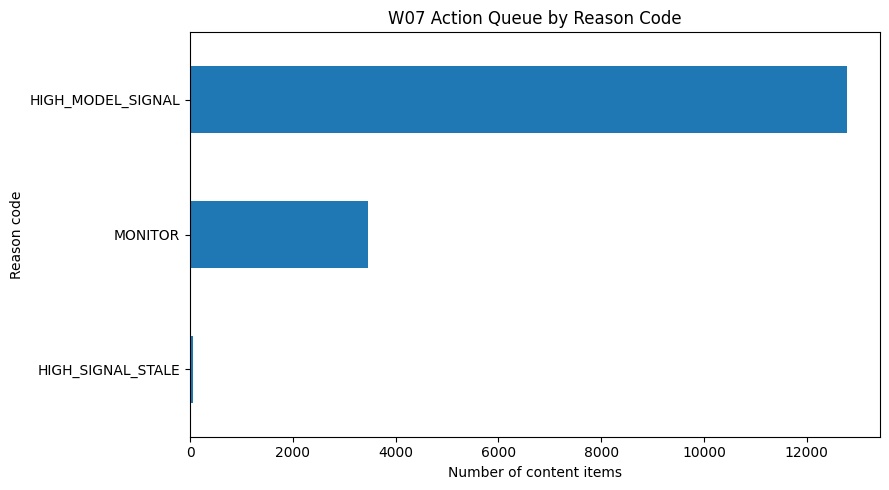

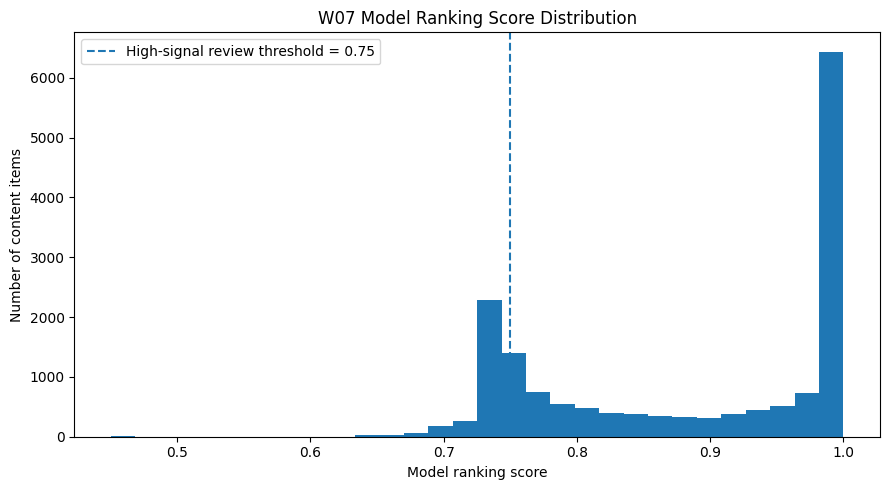

Figures created
work/figures/w07_reason_code_distribution.png
work/figures/w07_model_score_distribution.png

Existence check:
Reason figure: True
Score figure: True


In [10]:
# Section 5C: Generate figures for the paper

import matplotlib.pyplot as plt

FIGURE_DIR = Path("work/figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# Figure 1: Reason-code distribution
# ------------------------------------------------------------

reason_counts = (
    action_queue["reason_code"]
    .value_counts()
    .sort_values(ascending=True)
)

plt.figure(figsize=(9, 5))
reason_counts.plot(kind="barh")

plt.title("W07 Action Queue by Reason Code")
plt.xlabel("Number of content items")
plt.ylabel("Reason code")
plt.tight_layout()

reason_fig_path = FIGURE_DIR / "w07_reason_code_distribution.png"

plt.savefig(
    reason_fig_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# Figure 2: Model-score distribution
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

plt.hist(
    action_queue["model_score"],
    bins=30
)

plt.axvline(
    0.75,
    linestyle="--",
    linewidth=1.5,
    label="High-signal review threshold = 0.75"
)

plt.title("W07 Model Ranking Score Distribution")
plt.xlabel("Model ranking score")
plt.ylabel("Number of content items")
plt.legend()
plt.tight_layout()

score_fig_path = FIGURE_DIR / "w07_model_score_distribution.png"

plt.savefig(
    score_fig_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()


print("Figures created")
print("=" * 70)
print(reason_fig_path)
print(score_fig_path)

print("\nExistence check:")
print("Reason figure:", reason_fig_path.exists())
print("Score figure:", score_fig_path.exists())

## 6. Self-check

Before submission, verify that the playbook:

* uses the validated W05/W06 modeling population;
* produces a ranked queue with an explicit reason code and action;
* explains intended use and known limitations;
* distinguishes ranking signal from calibrated probability or causal effect;
* includes archetype-to-action mappings;
* requires human review before content changes;
* explicitly identifies actions that must not be automated;
* includes cost/value considerations without inventing monetary benefits;
* defines monitoring and retraining triggers;
* exports the queue for regeneration;
* exports committed metrics and reusable figures;
* and passes all data-quality checks.

The final artifact is a **practical, non-production human-review playbook**, not an autonomous content optimization system.


In [11]:
# Section 6: Final self-check

from pathlib import Path
import json
import pandas as pd

QUEUE_PATH = Path("work/outputs/w07_ranked_action_queue.csv")
METRICS_PATH = Path("work/outputs/w07_playbook_metrics.json")

REASON_FIG_PATH = Path(
    "work/figures/w07_reason_code_distribution.png"
)

SCORE_FIG_PATH = Path(
    "work/figures/w07_model_score_distribution.png"
)


# ------------------------------------------------------------
# File existence
# ------------------------------------------------------------

file_checks = {
    "queue_csv_exists": QUEUE_PATH.exists(),
    "metrics_json_exists": METRICS_PATH.exists(),
    "reason_figure_exists": REASON_FIG_PATH.exists(),
    "score_figure_exists": SCORE_FIG_PATH.exists(),
}


# ------------------------------------------------------------
# Queue consistency
# ------------------------------------------------------------

exported_queue = pd.read_csv(QUEUE_PATH)

queue_checks = {
    "queue_row_count_matches": len(exported_queue) == len(action_queue),
    "queue_rank_sequence_valid": (
        exported_queue["rank"].to_numpy()
        == np.arange(1, len(exported_queue) + 1)
    ).all(),
    "queue_scores_complete": exported_queue["model_score"].notna().all(),
    "queue_reasons_complete": exported_queue["reason_code"].notna().all(),
    "queue_actions_complete": exported_queue["action"].notna().all(),
}


# ------------------------------------------------------------
# Metrics consistency
# ------------------------------------------------------------

with open(METRICS_PATH, "r", encoding="utf-8") as f:
    exported_metrics = json.load(f)

metric_checks = {
    "metrics_rows_match": (
        exported_metrics["modeling_population_rows"]
        == len(model_df)
    ),
    "metrics_clients_match": (
        exported_metrics["unique_clients"]
        == model_df["client_hash_id"].nunique()
    ),
    "metrics_score_mean_match": np.isclose(
        exported_metrics["model_score"]["mean"],
        action_queue["model_score"].mean()
    ),
    "metrics_reason_counts_match": (
        exported_metrics["reason_code_counts"]
        ==
        {
            str(k): int(v)
            for k, v in action_queue["reason_code"]
            .value_counts()
            .to_dict()
            .items()
        }
    ),
    "metrics_action_counts_match": (
        exported_metrics["action_counts"]
        ==
        {
            str(k): int(v)
            for k, v in action_queue["action"]
            .value_counts()
            .to_dict()
            .items()
        }
    ),
}


# ------------------------------------------------------------
# Combine all checks
# ------------------------------------------------------------

all_checks = {
    **file_checks,
    **queue_checks,
    **metric_checks,
}

print("W07 FINAL SELF-CHECK")
print("=" * 70)

for check, passed in all_checks.items():
    print(f"{'PASS' if passed else 'FAIL'}  {check}")

print("\n" + "=" * 70)

if all(all_checks.values()):
    print("ALL W07 SELF-CHECKS PASSED")
else:
    failed = [
        check
        for check, passed in all_checks.items()
        if not passed
    ]
    raise AssertionError(
        "W07 self-check failed: " + ", ".join(failed)
    )

W07 FINAL SELF-CHECK
PASS  queue_csv_exists
PASS  metrics_json_exists
PASS  reason_figure_exists
PASS  score_figure_exists
PASS  queue_row_count_matches
PASS  queue_rank_sequence_valid
PASS  queue_scores_complete
PASS  queue_reasons_complete
PASS  queue_actions_complete
PASS  metrics_rows_match
PASS  metrics_clients_match
PASS  metrics_score_mean_match
PASS  metrics_reason_counts_match
PASS  metrics_action_counts_match

ALL W07 SELF-CHECKS PASSED
